In [ ]:
# 2. 로보플로우에서 데이터셋 다운로드하기
from pathlib import Path
from roboflow import Roboflow

rf = Roboflow(api_key="rbKxDcRU9ZeocS0l9Jqn")
project = rf.workspace("roboflow-100").project("road-traffic")  # 알약 데이터셋이면 실제 워크스페이스/프로젝트명으로 교체
dataset = project.version(1).download("yolov8")

base_dir = Path(dataset.location)   # 이후 절대 문자열로 되돌리지 말 것
print("다운로드 완료 경로:", base_dir.resolve())

# 3-2. 데이터셋 구조 확인
import yaml

yaml_path = base_dir / "data.yaml"
print("data.yaml 존재:", yaml_path.exists())
print("train 이미지 수:", len(list((base_dir / "train" / "images").glob("*"))))
print("valid 이미지 수:", len(list((base_dir / "valid" / "images").glob("*"))))

with open(yaml_path, "r", encoding="utf-8") as f:
    data_info = yaml.safe_load(f)
print("\n클래스 정보:", data_info.get("names"))

# 3-3. Road Traffic 객체 탐지 모델 학습
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"
model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=8,
    device=device,
    project="runs/road_traffic",
    name="yolov8n_traffic",
    patience=10,
    plots=True,
)

# 학습 직후 실제 저장 경로를 동적으로 확보 (하드코딩 금지)
save_dir = Path(model.trainer.save_dir)
best_model_path = save_dir / "weights" / "best.pt"

print("\n★ 학습 완료! best.pt 위치:", best_model_path.resolve())
assert best_model_path.exists(), "best.pt를 찾지 못했습니다. 학습이 정상 종료됐는지 확인하세요."

# 4. best.pt 불러와서 검증 이미지로 확인
import matplotlib.pyplot as plt
import cv2

best_model = YOLO(str(best_model_path))

valid_dir = base_dir / "valid" / "images"
image_files = list(valid_dir.glob("*.jpg")) + list(valid_dir.glob("*.jpeg")) + list(valid_dir.glob("*.png"))
if not image_files:
    raise FileNotFoundError(f"검증 이미지가 없습니다: {valid_dir}")

test_image = image_files[0]
result = best_model.predict(source=str(test_image), conf=0.25, verbose=False)[0]

image_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title(f"Road Traffic Detection: {test_image.name}")
plt.axis("off")
plt.show()

if result.boxes is None or len(result.boxes) == 0:
    print("탐지된 객체가 없습니다. conf=0.15로 낮춰 보세요.")
else:
    print(f"\n탐지 객체 수: {len(result.boxes)}개")
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = result.names[class_id]
        confidence = float(box.conf[0])
        print(f"- {class_name}: {confidence:.1%}")

# test(또는 valid) 세트 전체 예측 결과를 파일로 저장
test_images = list((base_dir / "test" / "images").glob("*")) or list(valid_dir.glob("*"))
if not test_images:
    raise FileNotFoundError("test 또는 valid/images 폴더에서 이미지 파일을 찾지 못했습니다.")

pred_results = best_model.predict(
    source=str(test_images[0]),
    conf=0.25,
    save=True,
    project="runs/road_traffic",
    name="prediction",
)
pred_save_dir = Path(pred_results[0].save_dir)
print("예측 결과 저장 폴더:", pred_save_dir.resolve())

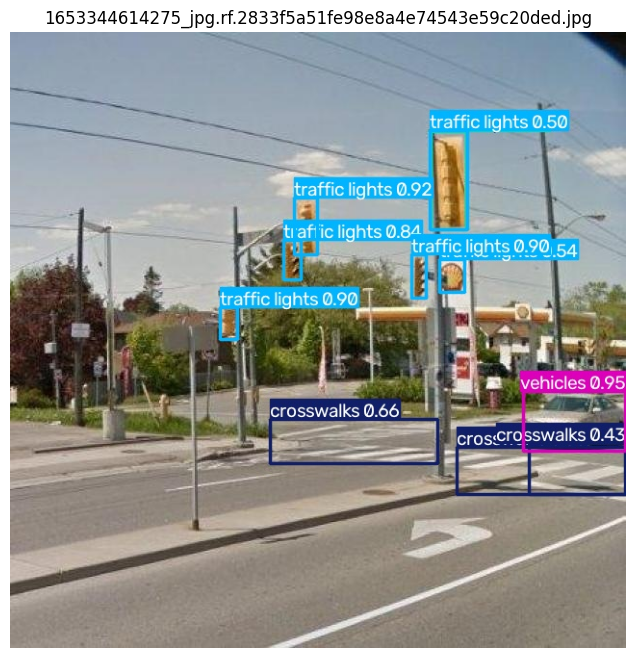

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

pred_dir = Path(r"C:\Users\kimkk\AppData\Local\Programs\Microsoft VS Code\runs\detect\runs\road_traffic\prediction")
result_images = list(pred_dir.glob("*.jpg"))

for img_path in result_images:
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()